# SVM Classifier — PD vs CN
Subject-level aggregation with adjustable SVM parameters.  
Runs in under a minute.

---

In [26]:
CYMO_CSV = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_CSV = './cymo_parkceleb_per_recording_metadata.csv'
FEAT_CSV = './mrmr_top10_features.csv'

In [27]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib, warnings
warnings.filterwarnings('ignore')
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, auc
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titleweight': 'bold'})

In [28]:
# Load and aggregate
cymo = pd.read_csv(CYMO_CSV)
meta = pd.read_csv(META_CSV)
features = pd.read_csv(FEAT_CSV)['feature'].tolist()
tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]
df = cymo.merge(meta[[meta_tid, 'group', 'subject']].drop_duplicates(),
                left_on=tid_col, right_on=meta_tid, how='inner')
df['label'] = (df['group'] == 'PD').astype(int)
for col in features:
    df[col] = pd.to_numeric(df.get(col, 0), errors='coerce')
df[features] = df[features].fillna(df[features].median())

agg = {f: ['mean', 'std'] for f in features}
agg['label'] = 'first'
subj = df.groupby('subject').agg(agg).reset_index()
subj.columns = ['subject'] + [f'{a}_{b}' if b else a for a, b in subj.columns[1:]]
label_col = [c for c in subj.columns if 'label' in c][0]
subj = subj.rename(columns={label_col: 'label'}).fillna(0)
feat_cols = [c for c in subj.columns if c not in ('subject', 'label')]
print(f'{len(subj)} subjects, {len(feat_cols)} features')

100 subjects, 48 features


In [29]:
# ╔══════════════════════════════════════════════════════════╗
# ║  ADJUST SVM PARAMETERS HERE                             ║
# ╚══════════════════════════════════════════════════════════╝
svm_configs = [
    # kernel,  C,     gamma
    #('rbf',    0.1,   'scale'),
    #('rbf',    0.5,   'scale'),
    #('rbf',    1.0,   'scale'),
    #('rbf',    5.0,   'scale'),
    #('rbf',    10.0,  'scale'),
    #('rbf',    1.0,   'auto'),
    #('rbf',    5.0,   'auto'),
    #('rbf',    1.0,   0.01),
    #('rbf',    1.0,   0.1),
    ('linear', 0.1,   'scale'),
    #('linear', 0.5,   'scale'),
    #('linear', 1.0,   'scale'),
    #('linear', 5.0,   'scale'),
    #('poly',   1.0,   'scale'),  # polynomial kernel
    #('poly',   5.0,   'scale'),
]

N_SPLITS = 20

In [30]:
results = []
for kernel, C, gamma in svm_configs:
    for seed in range(N_SPLITS):
        cn = subj[subj['label']==0].sample(frac=1, random_state=seed)
        pd_g = subj[subj['label']==1].sample(frac=1, random_state=seed)
        cs, ps = int(len(cn)*0.7), int(len(pd_g)*0.7)
        train = pd.concat([cn.iloc[:cs], pd_g.iloc[:ps]])
        test = pd.concat([cn.iloc[cs:], pd_g.iloc[ps:]])

        sc = StandardScaler()
        X_tr = sc.fit_transform(train[feat_cols].values)
        X_te = sc.transform(test[feat_cols].values)
        y_te = test['label'].values

        svm = SVC(kernel=kernel, C=C, gamma=gamma,
                  class_weight='balanced', probability=True, random_state=42)
        svm.fit(X_tr, train['label'].values)
        y_prob = svm.predict_proba(X_te)[:, 1]
        y_pred = svm.predict(X_te)

        results.append({
            'kernel': kernel, 'C': C, 'gamma': str(gamma), 'seed': seed,
            'acc': accuracy_score(y_te, y_pred),
            'auc': roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5,
            'f1': f1_score(y_te, y_pred, zero_division=0),
            'sens': recall_score(y_te, y_pred, zero_division=0),
            'spec': recall_score(y_te, y_pred, pos_label=0, zero_division=0),
        })

res_df = pd.DataFrame(results)
res_df['config'] = res_df.apply(lambda r: f"{r['kernel']} C={r['C']} γ={r['gamma']}", axis=1)
print(f'Done: {len(res_df)} experiments')

Done: 20 experiments


In [31]:
# Summary
summary = res_df.groupby('config').agg(
    acc=('acc','mean'), acc_std=('acc','std'),
    auc=('auc','mean'), auc_std=('auc','std'),
    f1=('f1','mean'), sens=('sens','mean'), spec=('spec','mean'),
).sort_values('auc', ascending=False).round(3)

print(f'{"Config":<30s} {"Acc":>12s} {"AUC":>12s} {"F1":>6s} {"Sens":>6s} {"Spec":>6s}')
print('─' * 75)
for cfg, r in summary.iterrows():
    print(f'{cfg:<30s} {r["acc"]:.3f}±{r["acc_std"]:.3f} '
          f'{r["auc"]:.3f}±{r["auc_std"]:.3f} {r["f1"]:.3f} {r["sens"]:.3f} {r["spec"]:.3f}')

Config                                  Acc          AUC     F1   Sens   Spec
───────────────────────────────────────────────────────────────────────────
linear C=0.1 γ=scale           0.828±0.069 0.890±0.060 0.778 0.762 0.872


In [32]:
# Train best config and save
best_cfg_name = summary.index[0]
best_row = res_df[res_df['config'] == best_cfg_name].iloc[0]

np.random.seed(42)
cn = subj[subj['label']==0].sample(frac=1, random_state=42)
pd_g = subj[subj['label']==1].sample(frac=1, random_state=42)
cs, ps = int(len(cn)*0.7), int(len(pd_g)*0.7)
train = pd.concat([cn.iloc[:cs], pd_g.iloc[:ps]])
test = pd.concat([cn.iloc[cs:], pd_g.iloc[ps:]])

sc = StandardScaler()
X_tr = sc.fit_transform(train[feat_cols].values)
X_te = sc.transform(test[feat_cols].values)

best_svm = SVC(kernel=best_row['kernel'], C=best_row['C'],
gamma=best_row['gamma'] if best_row['gamma'] in ('scale', 'auto') else float(best_row['gamma']),
class_weight='balanced', probability=True, random_state=42)
best_svm.fit(X_tr, train['label'].values)

y_pred = best_svm.predict(X_te)
y_prob = best_svm.predict_proba(X_te)[:, 1]
y_te = test['label'].values

print(f'Best: {best_cfg_name}')
print(f'  Acc={accuracy_score(y_te,y_pred):.3f}  AUC={roc_auc_score(y_te,y_prob):.3f}  '
      f'F1={f1_score(y_te,y_pred):.3f}')

joblib.dump({'model': best_svm, 'scaler': sc, 'features': feat_cols,
             'base_features': features, 'aggregation': 'subject_mean_std'}, 'svm_best.joblib')
print('Saved: svm_best.joblib')

Best: linear C=0.1 γ=scale
  Acc=0.900  AUC=0.963  F1=0.870
Saved: svm_best.joblib


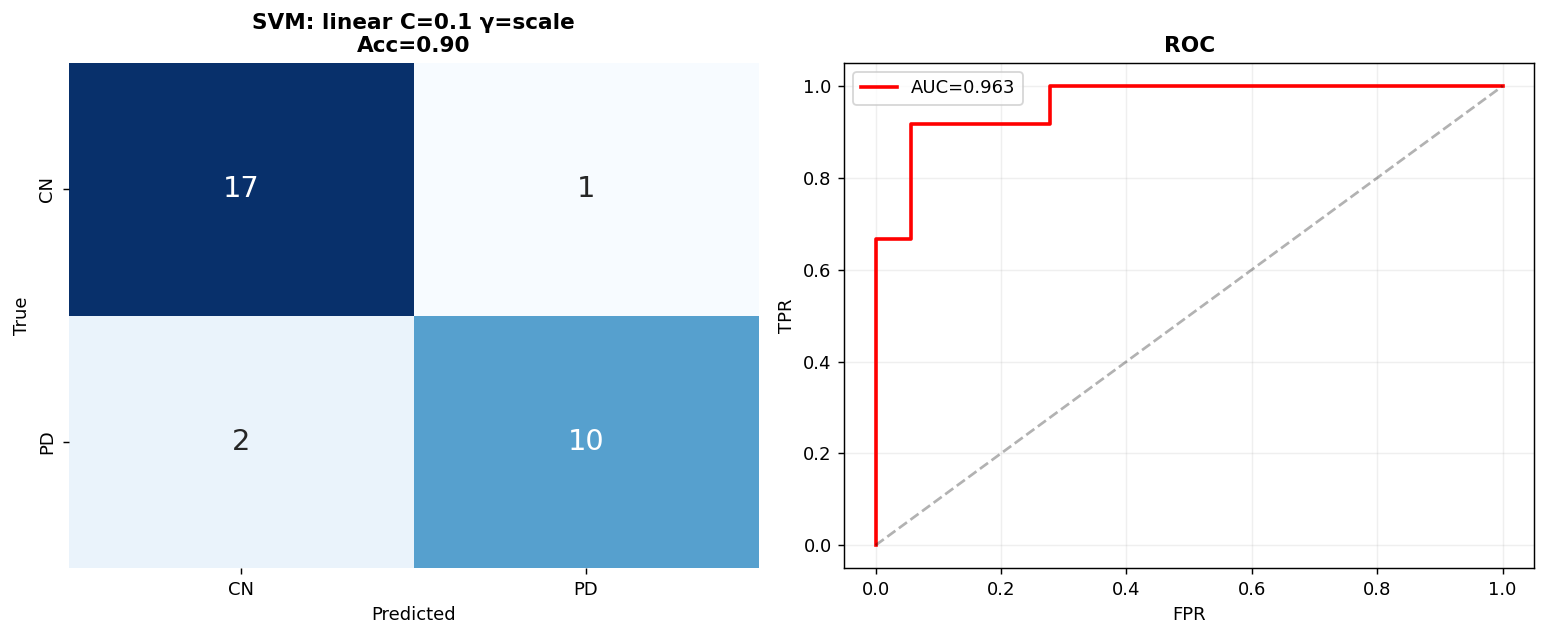

In [33]:
# Visuals
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['CN','PD'], yticklabels=['CN','PD'], cbar=False, annot_kws={'size':16})
axes[0].set_title(f'SVM: {best_cfg_name}\nAcc={accuracy_score(y_te,y_pred):.2f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

fpr, tpr, _ = roc_curve(y_te, y_prob)
axes[1].plot(fpr, tpr, 'r-', lw=2, label=f'AUC={roc_auc_score(y_te,y_prob):.3f}')
axes[1].plot([0,1],[0,1],'k--',alpha=0.3); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC'); axes[1].legend(); axes[1].grid(alpha=0.2)
plt.tight_layout(); plt.savefig('svm_results.png', dpi=150, bbox_inches='tight'); plt.show()